In [19]:
import soundfile as sf
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import spectrogram
# Read an audio file
audio_data, sample_rate = sf.read("../soundfiles/Beethoven_ String Quartet #16 In F, Op. 135 - 1. Allegretto.mp3")

# Write to a WAV file
sf.write("../soundfiles/spectrogram_file.wav", audio_data, sample_rate)

print("Audio conversion successful!")


Audio conversion successful!


audio data: (17631360, 2)


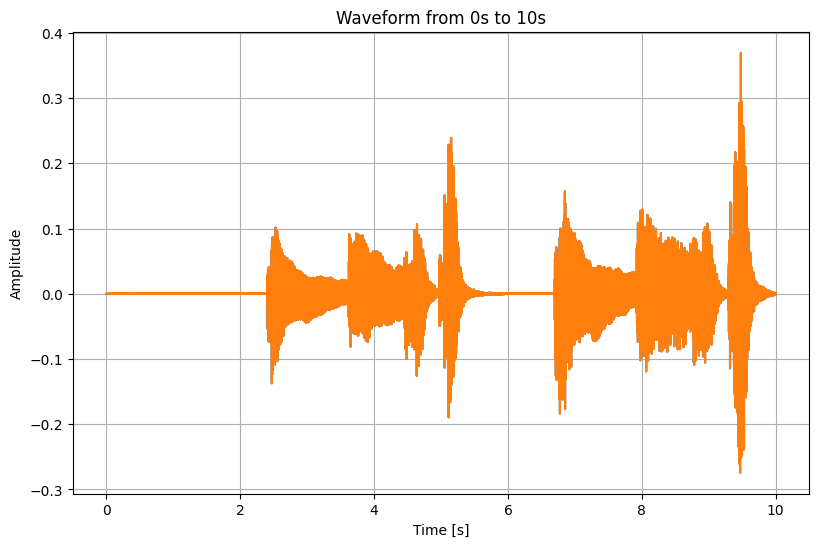

(257, 590)


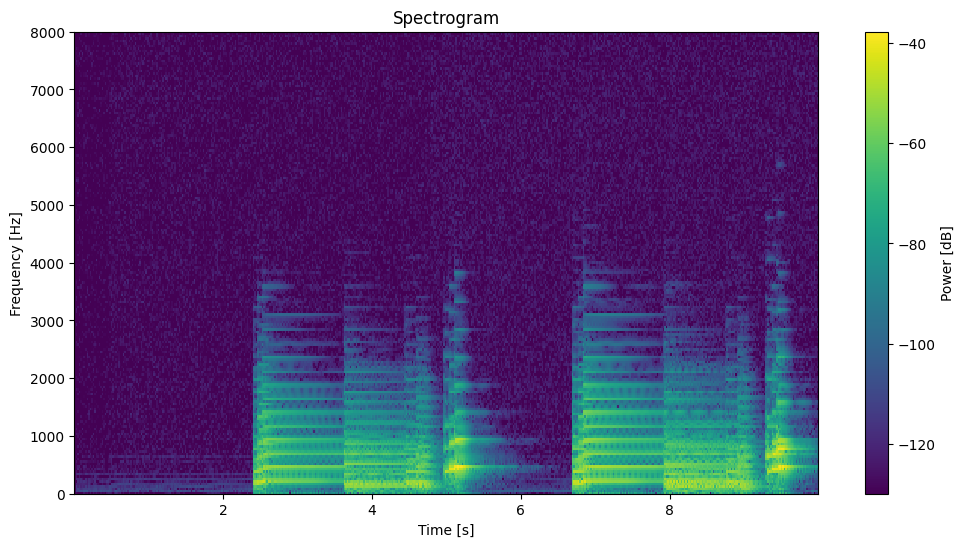

In [35]:
# Load the audio file
audio_data, sample_rate = sf.read("/workspace/soundfiles/spectrogram_file.wav")

print(f'audio data: {audio_data.shape}')

# Create a time axis in seconds
duration = len(audio_data) / sample_rate  # total duration of the audio
time = np.linspace(0., duration, len(audio_data))

# Define the range you want to zoom into (e.g., from 2 to 5 seconds)
start_time = 0  # seconds
end_time = 10    # seconds

# Find the indices that correspond to these times
start_index = int(start_time * sample_rate)
end_index = int(end_time * sample_rate)

# Slice the audio data and time arrays
zoomed_audio = audio_data[start_index:end_index]
zoomed_time = time[start_index:end_index]

# Plot the zoomed-in waveform
plt.figure(figsize=(9.5, 6))
plt.plot(zoomed_time, zoomed_audio)
plt.title(f"Waveform from {start_time}s to {end_time}s")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


# Generate the spectrogram
f, t, Sxx = spectrogram(zoomed_audio[:,0], fs=sample_rate, nperseg=512)

print(Sxx.shape)

# Avoid taking log of zero by replacing zero values in Sxx with a small value
Sxx = np.where(Sxx <= 1e-13, 1e-13, Sxx)  # Replace zeros with a small value

# Plot the spectrogram (convert to dB scale)
plt.figure(figsize=(12, 6))
plt.pcolormesh(t+start_time, f, 10 * np.log10(Sxx))  # Convert power to dB
plt.title("Spectrogram")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.colorbar(label="Power [dB]")
plt.ylim(0, 8000)  # Optional: limit frequency range to 10 kHz
plt.show()

In [70]:
440*2**((note_labels[1]-49)/12)

np.float64(830.6093951598903)

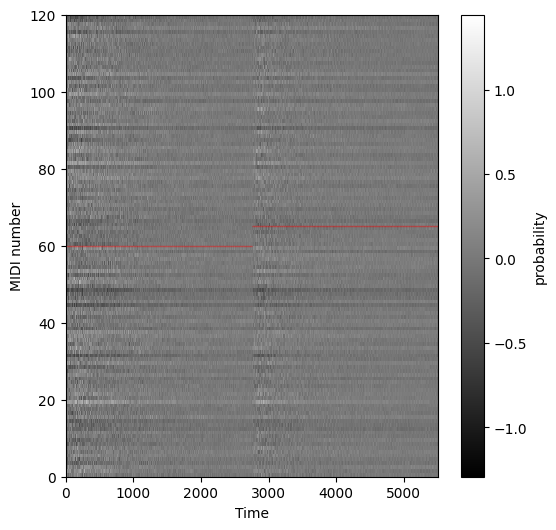

In [161]:
import os
def spectrogramOfTestData(nbinsX,start_time=0,end_time=2,folder_name_input="output/folder_1/",folder_name_output=("example_data/")):
    # Load the audio file
    audio_data, sample_rate = sf.read(os.path.join(folder_name_input, "melody_trimmed.wav"))

    # Create a time axis in seconds
    duration = len(audio_data) / sample_rate  # total duration of the audio
    time = np.linspace(0., duration, len(audio_data))

    # Find the indices that correspond to these times
    start_index = int(start_time * sample_rate)
    end_index = int(end_time * sample_rate)

    # Slice the audio data and time arrays
    zoomed_audio = audio_data[start_index:end_index]
    zoomed_time = time[start_index:end_index]

    # Load the notes file
    note_labels = np.load(os.path.join(folder_name_input,"notes.npy"))
    note_labels_downsampled=note_labels[::round(len(note_labels)/(nbinsX-1))]
    actual_notes = 440*2**((note_labels_downsampled-69)/12)

    predicted_notes = np.load(os.path.join(folder_name_output,"example_output.npy"))[1] 
    plt.figure(figsize=(6, 6))
    plt.pcolormesh(predicted_notes.T,cmap='gray')
    for i in range(0,nbinsX-1):
        plt.axhline(y=note_labels_downsampled[i], color='red', alpha=0.2, linewidth=1, xmin=i/nbinsX,xmax=(i+1)/nbinsX)
    plt.xlabel("Time")
    plt.ylabel("MIDI number")
    plt.colorbar(label="probability")
    plt.show()
    # # Generate the spectrogram
    # f, t, Sxx = spectrogram(zoomed_audio[:,0], fs=sample_rate, nperseg=1024)

    # # Avoid taking log of zero by replacing zero values in Sxx with a small value
    # Sxx = np.where(Sxx <= 1e-13, 1e-13, Sxx)  # Replace zeros with a small value

    # # Plot the spectrogram (convert to dB scale)
    # plt.figure(figsize=(6, 6))
    # plt.pcolormesh(t, np.log10(f+1e-10), np.log10(Sxx),cmap='viridis', vmin=-10, vmax=-5)
    # for i in range(0,nbinsX-1):
    #     plt.axhline(y=np.log10(actual_notes[i]), color='red', linewidth=1, xmin=i/nbinsX,xmax=(i+1)/nbinsX)
    # plt.title("Spectrogram")
    # plt.xlabel("Time [s]")
    # plt.ylabel("log(Frequency [Hz])")
    # plt.colorbar(label="Power [dB]")
    # plt.ylim(np.log10(27.5), np.log10(4186))  # Optional: limit frequency range to 10 kHz
    # plt.show()

spectrogramOfTestData(nbinsX=5500)

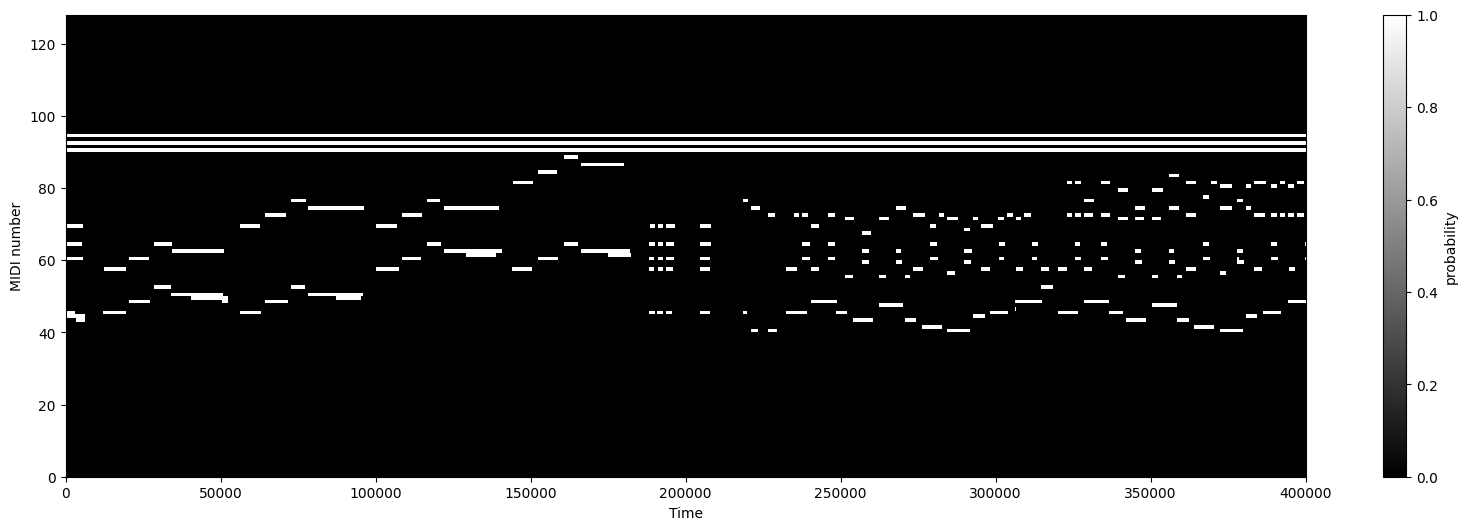

In [180]:
from scipy.sparse import load_npz

piano_roll = load_npz(os.path.join("example_data2/wav_output/", "piano_roll_sparse.npz"))
dense_piano_roll = piano_roll.toarray()

plt.figure(figsize=(20, 6))
plt.pcolormesh(dense_piano_roll[1000000:1400000].T,cmap='gray')
plt.xlabel("Time")
plt.ylabel("MIDI number")
plt.colorbar(label="probability")
plt.show()

In [174]:
dense_piano_roll.shape

(4849796, 128)

In [ ]:
import torch

In [4]:
from model_audio_transriber import AudioSegmentationModel

In [7]:
audio_model = AudioSegmentationModel(
    num_notes=10,
    cnn_kernel_size=14,
    cnn_num_layers=4,
    transformer_num_layers=2,
    transformer_d_model=64,
    transformer_nhead=4,
    transformer_dim_feedforward=64,
    cnn_stride=4
).to('cpu')

In [8]:
audio_data_torch = torch.tensor(audio_data, device="cpu", dtype=torch.float32)

In [9]:
output = audio_model.forward(audio_data_torch.unsqueeze(0))

RuntimeError: [enforce fail at alloc_cpu.cpp:117] err == 0. DefaultCPUAllocator: can't allocate memory: you tried to allocate 75895842064 bytes. Error code 12 (Cannot allocate memory)

In [ ]:
output.shape

torch.Size([1, 68873, 10])

In [ ]:
import numpy as np
import soundfile as sf
import os

def load_melody(folder_path):
    wav_path = os.path.join(folder_path, "melody.wav")
    notes_path = os.path.join(folder_path, "melody_notes.npy")

    # Load audio
    audio_data, sample_rate = sf.read(wav_path)

    # Load note array
    note_array = np.load(notes_path)

    return audio_data, sample_rate, note_array


In [13]:
import os
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import torchaudio

#########################################
# Downsample function (given in prompt) #
#########################################
def downsample_note_array(note_array, target_length):
    original_length = len(note_array)
    indices = np.linspace(0, original_length - 1, num=target_length, dtype=int)
    return note_array[indices]

##########################################
# Custom Dataset for loading data pairs  #
##########################################
class MelodyNotesDataset(Dataset):
    def __init__(self, folder_path, input_seq_len=512, label_seq_len=128):
        """
        - folder_path: top-level folder containing subfolders
          each with melody.wav and notes.npy
        - input_seq_len: length to which we downsample the input
        - label_seq_len: length to which we downsample the target
        """
        self.samples = []
        self.input_seq_len = input_seq_len
        self.label_seq_len = label_seq_len
        
        for sub in os.listdir(folder_path):
            sub_path = os.path.join(folder_path, sub)
            if os.path.isdir(sub_path):
                wav_path = os.path.join(sub_path, "melody_trimmed.wav")
                notes_path = os.path.join(sub_path, "notes.npy")
                print(wav_path)
                print(notes_path)
                print(os.path.isfile(wav_path))
                print(os.path.isfile(notes_path))
                if os.path.isfile(wav_path) and os.path.isfile(notes_path):
                    self.samples.append((wav_path, notes_path))
        print(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        wav_path, notes_path = self.samples[idx]
        # Load audio
        waveform, sr = torchaudio.load(wav_path)  # shape: (channels, time)
        waveform = waveform.mean(dim=0).numpy()   # convert to mono, shape: (time,)

        # Load notes
        notes = np.load(notes_path)  # shape: (time, ) or (time, something)

        # Downsample to get a fixed input shape
        wave_down = downsample_note_array(waveform, self.input_seq_len)
        notes_down_input = downsample_note_array(notes, self.input_seq_len)
        
        # Construct the (seq_len, 2) input
        # Assuming 'notes' is 1D; if it's multi-dimensional, adapt the stacking logic
        x_input = np.stack([wave_down, notes_down_input], axis=-1)

        # Downsample to get label shape (often smaller or same size):
        y_label = downsample_note_array(notes, self.label_seq_len)

        # Convert to Torch
        x_input = torch.from_numpy(x_input).float()  # shape: (seq_len, 2)
        y_label = torch.from_numpy(y_label).float()  # shape: (label_seq_len,) or (label_seq_len, ...)

        return x_input, y_label

########################################
# Main training function / training loop
########################################
def train_model(
    folder_path,
    model,
    optimizer,
    device="cuda",
    epochs=10,
    batch_size=4,
    input_seq_len=512,
    label_seq_len=128
):
    # Create dataset & loader
    dataset = MelodyNotesDataset(
        folder_path,
        input_seq_len=input_seq_len,
        label_seq_len=label_seq_len
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    # Move model to device
    model.to(device)
    model.train()

    for epoch in range(epochs):
        total_loss = 0.0
        for x_input, y_label in loader:
            # Move data to device
            x_input = x_input.to(device)           # (batch, seq_len, 2)
            y_label = y_label.to(device)           # (batch, label_seq_len, ...) depending on your model
            # Forward pass
            optimizer.zero_grad()
            y_pred = model(x_input)
            # Example loss: MSE
            # If y_pred is (batch, label_seq_len, num_notes) but y_label is (batch, label_seq_len),
            # you may need to reshape or pick a suitable loss. Here we do a naive MSE:
            loss = F.cross_entropy(y_pred.transpose(1, 2), y_label.long())

            # Backward + update
            loss.backward()
            optimizer.step()

            # Accumulate loss
            total_loss += loss.item() * x_input.size(0)

        # Compute average loss
        avg_loss = total_loss / len(dataset)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")


In [11]:
audio_model = AudioSegmentationModel(
    num_notes=120,
    cnn_kernel_size=14,
    cnn_num_layers=4,
    transformer_num_layers=2,
    transformer_d_model=64,
    transformer_nhead=4,
    transformer_dim_feedforward=64,
    cnn_stride=4
)

In [18]:
optimizer = torch.optim.Adam(params=audio_model.parameters(), lr=1e-5)
train_model(folder_path="/workspace/src/output", model=audio_model, optimizer=optimizer, batch_size=2, input_seq_len=88000, label_seq_len=345, device="cpu", epochs=1000)

/workspace/src/output/folder_1/melody_trimmed.wav
/workspace/src/output/folder_1/notes.npy
True
True
/workspace/src/output/folder_3/melody_trimmed.wav
/workspace/src/output/folder_3/notes.npy
True
True
/workspace/src/output/folder_2/melody_trimmed.wav
/workspace/src/output/folder_2/notes.npy
True
True
[('/workspace/src/output/folder_1/melody_trimmed.wav', '/workspace/src/output/folder_1/notes.npy'), ('/workspace/src/output/folder_3/melody_trimmed.wav', '/workspace/src/output/folder_3/notes.npy'), ('/workspace/src/output/folder_2/melody_trimmed.wav', '/workspace/src/output/folder_2/notes.npy')]
Epoch [1/1000], Loss: 3.2010
Epoch [2/1000], Loss: 3.2010
Epoch [3/1000], Loss: 3.2010
Epoch [4/1000], Loss: 3.2010
Epoch [5/1000], Loss: 2.8681
Epoch [6/1000], Loss: 2.8681
Epoch [7/1000], Loss: 3.2010
Epoch [8/1000], Loss: 2.8680
Epoch [9/1000], Loss: 3.2010
Epoch [10/1000], Loss: 2.8680
Epoch [11/1000], Loss: 3.2010
Epoch [12/1000], Loss: 3.2010
Epoch [13/1000], Loss: 2.8681
Epoch [14/1000], L

KeyboardInterrupt: 